# Model Tuning

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

In [3]:
df = pd.read_csv('../data/Bank Customer Churn Prediction.csv')
df.columns = df.columns.str.lower()
df = df.drop(columns=['customer_id', 'surname'], errors='ignore')

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns = ['churn'])
y = df_encoded['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(X_train.shape)

(8000, 11)


### Set Up & Execution of GridSearchCV

In [4]:
base_catboost = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)

param_grid = {
    'iterations': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    'depth': [4, 5, 6, 7, 8],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}

grid_search = GridSearchCV(
    estimator=base_catboost,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best Hyperparameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 750 candidates, totalling 3750 fits
Best Hyperparameters Found: {'depth': 5, 'iterations': 200, 'l2_leaf_reg': 9, 'learning_rate': 0.05}
Best Cross-Validation ROC-AUC Score: 0.8709


### Testing the Fine-Tuned Model

In [5]:
final_bank_model = grid_search.best_estimator_

y_pred = final_bank_model.predict(X_test)
y_prob = final_bank_model.predict_proba(X_test)[:, 1]

print("Final Tuned Model Info: \n")

print(f"Test Set ROC-AUC score: {roc_auc_score(y_test, y_prob):.4f}\n")
print(f"Performance Matrix: \n {classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)'])}")

Final Tuned Model Info: 

Test Set ROC-AUC score: 0.8759

Performance Matrix: 
               precision    recall  f1-score   support

Retained (0)       0.88      0.97      0.92      1593
 Churned (1)       0.81      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.85      0.73      0.77      2000
weighted avg       0.87      0.87      0.86      2000



### Feature Map
#### Below I added a feature map to see what the model values the highest when it comes to cheking whether or not someone is about to churn. Specifically looking at the top 3, as this would be important information for a bank so that they would be more focused on these variables and their values specifically.

/var/folders/sv/vlmp_y0x7674xh0d1j95w4zr0000gn/T/ipykernel_9295/2838600019.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


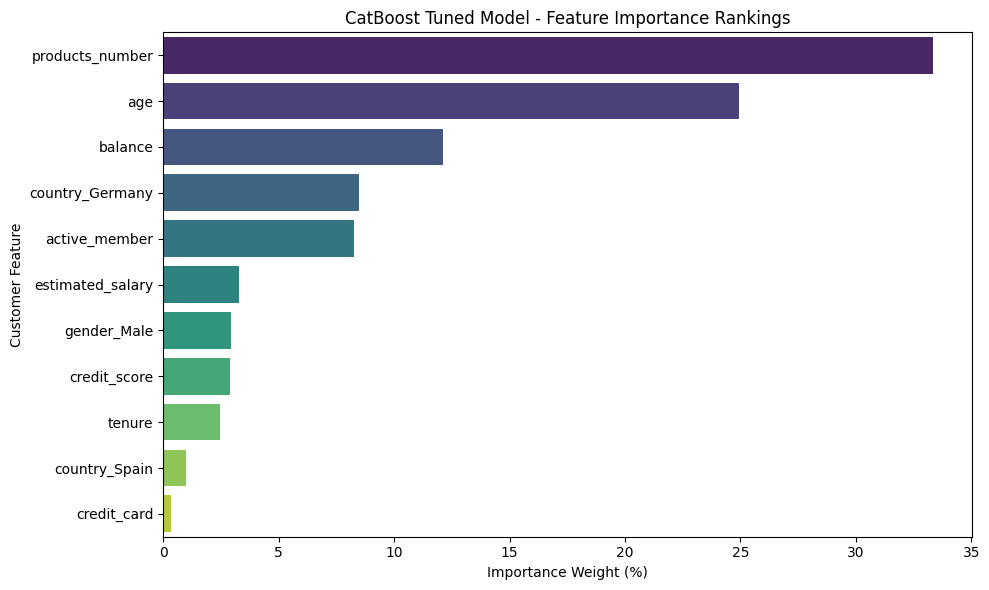

Top 3 Churn Drivers
        Feature  Importance
products_number   33.347143
            age   24.931178
        balance   12.125806


In [6]:
importance_scores = final_bank_model.get_feature_importance()

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('CatBoost Tuned Model - Feature Importance Rankings')
plt.xlabel('Importance Weight (%)')
plt.ylabel('Customer Feature')
plt.tight_layout()
plt.show()

print("Top 3 Churn Drivers")
print(importance_df.head(3).to_string(index=False))
